# Phan C — Huan luyen & Danh gia 5 Mo hinh Classifier

**Flow:** Load `train.pkl`, `val.pkl`, `test.pkl` -> Train 5 mo hinh -> So sanh ket qua

| Mo hinh | Thu vien |
|---|---|
| Linear Regression (threshold=0.5) | sklearn |
| Random Forest | sklearn |
| XGBoost | xgboost |
| LightGBM | lightgbm |
| CatBoost | catboost |


In [ ]:
# Cai dat cac thu vien can thiet
!pip install xgboost lightgbm catboost scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
print("--- Kết nối Google Drive ---")
drive.mount('/content/drive')

--- Kết nối Google Drive ---
Mounted at /content/drive


In [ ]:
import pickle
import numpy as np
# -------------------------------------------------------
# Load du lieu da xu ly tu phan A+B
# -------------------------------------------------------
# Co the thay doi duong dan neu can
PKL_DIR = '/content/drive/MyDrive/Deepfake_project/features/'

with open(PKL_DIR + 'train.pkl', 'rb') as f:
    train_data = pickle.load(f)

with open(PKL_DIR + 'val.pkl', 'rb') as f:
    val_data = pickle.load(f)

with open(PKL_DIR + 'test.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train, y_train = train_data['X'], train_data['y']
X_val,   y_val   = val_data['X'],   val_data['y']
X_test,  y_test  = test_data['X'],  test_data['y']

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Nhan - 0=Real, 1=Fake | Train: {np.bincount(y_train)}')


Train: (32000, 187), Val: (4000, 187), Test: (4000, 187)
Nhan - 0=Real, 1=Fake | Train: [16000 16000]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# Dinh nghia 5 mo hinh
# -------------------------------------------------------
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        random_seed=42,
        verbose=0
    )
}

# -------------------------------------------------------
# Ham danh gia chung
# -------------------------------------------------------
def evaluate(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, is_lr=False):
    """Train va tra ve dict cac chi so tren val + test."""
    model.fit(X_tr, y_tr)

    if is_lr:
        # LinearRegression: dung nguong 0.5 de phan loai
        y_val_pred  = (model.predict(X_v)  >= 0.5).astype(int)
        y_test_pred = (model.predict(X_te) >= 0.5).astype(int)
        y_val_prob  = np.clip(model.predict(X_v),  0, 1)
        y_test_prob = np.clip(model.predict(X_te), 0, 1)
    else:
        y_val_pred  = model.predict(X_v)
        y_test_pred = model.predict(X_te)
        if hasattr(model, 'predict_proba'):
            y_val_prob  = model.predict_proba(X_v)[:, 1]
            y_test_prob = model.predict_proba(X_te)[:, 1]
        else:
            y_val_prob  = y_val_pred.astype(float)
            y_test_prob = y_test_pred.astype(float)

    row = {
        'Model': name,
        'Val Acc':   accuracy_score(y_v,  y_val_pred),
        'Val F1':    f1_score(y_v,  y_val_pred),
        'Val AUC':   roc_auc_score(y_v,  y_val_prob),
        'Test Acc':  accuracy_score(y_te, y_test_pred),
        'Test F1':   f1_score(y_te, y_test_pred),
        'Test AUC':  roc_auc_score(y_te, y_test_prob),
    }

    print(f'\n=== {name} ===')
    print(f"  Val  -> Acc:{row['Val Acc']:.4f}  F1:{row['Val F1']:.4f}  AUC:{row['Val AUC']:.4f}")
    print(f"  Test -> Acc:{row['Test Acc']:.4f}  F1:{row['Test F1']:.4f}  AUC:{row['Test AUC']:.4f}")
    print('  [Test] Classification Report:')
    print(classification_report(y_te, y_test_pred,
                                target_names=['Real','Fake']))
    return row, model

# -------------------------------------------------------
# Huan luyen & danh gia tung mo hinh
# -------------------------------------------------------
results = []
trained_models = {}

for name, clf in models.items():
    is_lr = (name == 'LinearRegression')
    row, fitted = evaluate(
        name, clf,
        X_train, y_train,
        X_val,   y_val,
        X_test,  y_test,
        is_lr=is_lr
    )
    results.append(row)
    trained_models[name] = fitted

# -------------------------------------------------------
# Bang tong ket
# -------------------------------------------------------
df_results = pd.DataFrame(results).set_index('Model')
print('\n\n========== TONG KET CAC MO HINH ==========')
print(df_results.to_string(float_format='{:.4f}'.format))



=== LinearRegression ===
  Val  -> Acc:0.8535  F1:0.8556  AUC:0.9321
  Test -> Acc:0.8552  F1:0.8574  AUC:0.9309
  [Test] Classification Report:
              precision    recall  f1-score   support

        Real       0.87      0.84      0.85      2000
        Fake       0.85      0.87      0.86      2000

    accuracy                           0.86      4000
   macro avg       0.86      0.86      0.86      4000
weighted avg       0.86      0.86      0.86      4000


=== RandomForest ===
  Val  -> Acc:0.8355  F1:0.8346  AUC:0.9121
  Test -> Acc:0.8350  F1:0.8338  AUC:0.9144
  [Test] Classification Report:
              precision    recall  f1-score   support

        Real       0.83      0.84      0.84      2000
        Fake       0.84      0.83      0.83      2000

    accuracy                           0.83      4000
   macro avg       0.84      0.83      0.83      4000
weighted avg       0.84      0.83      0.83      4000


=== XGBoost ===
  Val  -> Acc:0.8680  F1:0.8685  AUC:0.94

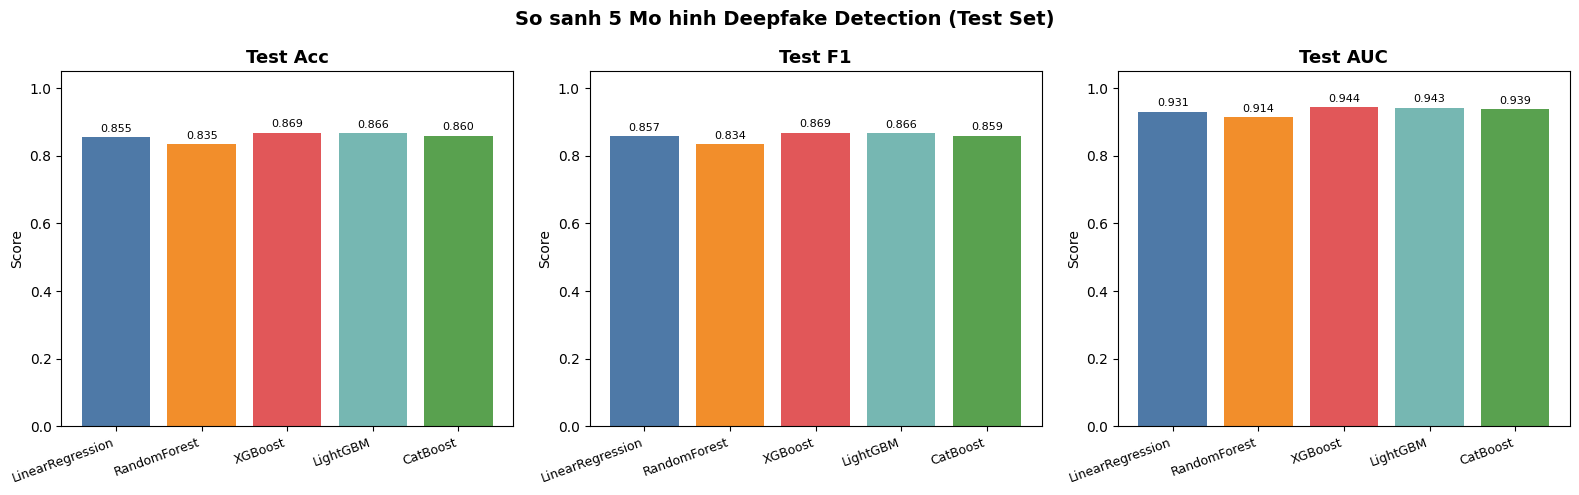

[Saved] model_comparison.png


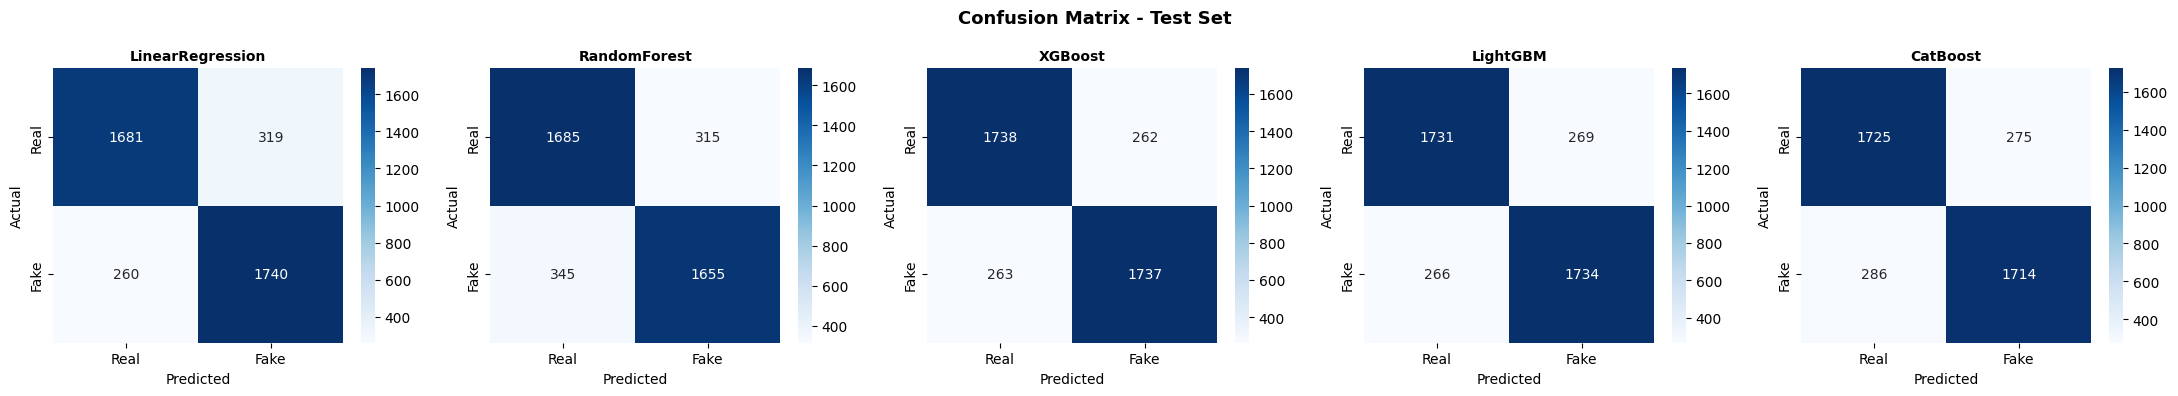

[Saved] confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -------------------------------------------------------
# 1. Bar chart so sanh cac mo hinh
# -------------------------------------------------------
metrics = ['Test Acc', 'Test F1', 'Test AUC']
df_plot = df_results[metrics].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(df_plot.index, df_plot[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_xticklabels(df_plot.index, rotation=20, ha='right', fontsize=9)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('So sanh 5 Mo hinh Deepfake Detection (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Deepfake_project/figure/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] model_comparison.png')

# -------------------------------------------------------
# 2. Confusion Matrix cho tung mo hinh
# -------------------------------------------------------
fig2, axes2 = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, clf) in zip(axes2, trained_models.items()):
    is_lr = (name == 'LinearRegression')
    if is_lr:
        y_pred = (clf.predict(X_test) >= 0.5).astype(int)
    else:
        y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real','Fake'],
                yticklabels=['Real','Fake'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig2.suptitle('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Deepfake_project/figure/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('[Saved] confusion_matrices.png')


In [ ]:
import pickle

# Luu tat ca mo hinh da huan luyen
for name, clf in trained_models.items():
    filename = f'{name.lower().replace(" ","_")}_model.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(clf, f)
    print(f'[Saved] {filename}')

# Luu bang tong ket
df_results.to_csv('model_results.csv')
print('[Saved] model_results.csv')

print('\n[DONE] Hoan thanh huan luyen & luu tat ca 5 mo hinh!')
print(df_results.to_string(float_format='{:.4f}'.format))


[Saved] linearregression_model.pkl
[Saved] randomforest_model.pkl
[Saved] xgboost_model.pkl
[Saved] lightgbm_model.pkl
[Saved] catboost_model.pkl
[Saved] model_results.csv

[DONE] Hoan thanh huan luyen & luu tat ca 5 mo hinh!
                  Val Acc  Val F1  Val AUC  Test Acc  Test F1  Test AUC
Model                                                                  
LinearRegression   0.8535  0.8556   0.9321    0.8552   0.8574    0.9309
RandomForest       0.8355  0.8346   0.9121    0.8350   0.8338    0.9144
XGBoost            0.8680  0.8685   0.9415    0.8688   0.8687    0.9442
LightGBM           0.8690  0.8700   0.9424    0.8662   0.8664    0.9427
CatBoost           0.8602  0.8608   0.9360    0.8598   0.8594    0.9386
